# The Death of the Mid-Budget Movie? An EDA of Hollywood Film Economics, 1990–2015

**A capstone exploratory data analysis project**

**Research question:** Has Hollywood shifted away from mid-budget filmmaking toward a "barbell" of micro-budget and tentpole releases — and if so, what does the data actually support versus what's commonly assumed?

**Dataset:** [TMDB 5000 Movie Dataset](https://www.kaggle.com/tmdb/tmdb-movie-metadata) — 4,803 films with budget, revenue, genre, release date, runtime, and audience rating.

**Contents**
1. Data Loading & Cleaning
2. Feature Engineering (inflation adjustment, budget tiers, genre parsing)
3. Exploratory Analysis — budget tier trends over time
4. Critical Check: Sampling Bias in the Dataset
5. Statistical Modeling — what predicts box office revenue?
6. Conclusions & Limitations


## 1. Data Loading & Cleaning

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import matplotlib
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df = pd.read_csv('tmdb_movies.csv')
print(f"Raw shape: {df.shape}")
df.head(3)


Raw shape: (4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


### 1.1 Missingness check

Before doing anything else, we check what's actually missing or malformed. `homepage` and `tagline`
are expected to be sparse (older/smaller films often didn't have either) and aren't used in this
analysis, so we leave them. `budget` and `revenue` don't have NaNs, but — as is well known with this
dataset — many are populated with **zero**, which is not a real value (no film has a $0 budget); this
is missingness disguised as a number, and has to be handled explicitly or it will silently corrupt
every ratio calculated from it.

In [2]:
missing = df.isnull().sum()
zero_budget = (df['budget'] == 0).sum()
zero_revenue = (df['revenue'] == 0).sum()

print("Nulls per column (non-zero only):")
print(missing[missing > 0])
print(f"\nRows with budget == 0:  {zero_budget}  ({zero_budget/len(df):.1%} of dataset)")
print(f"Rows with revenue == 0: {zero_revenue}  ({zero_revenue/len(df):.1%} of dataset)")


Nulls per column (non-zero only):
homepage        3091
overview           3
release_date       1
runtime            2
tagline          844
dtype: int64

Rows with budget == 0:  1037  (21.6% of dataset)
Rows with revenue == 0: 1427  (29.7% of dataset)


Roughly a third of the dataset has zero-filled budget or revenue. These aren't real data points —
they're unreported values — so they're dropped for any analysis involving those columns, rather than
being treated as legitimate $0 films. We also parse `release_date` into a proper datetime and extract
`year`, and restrict the analysis window to **1990–2015**: earlier years have too few titles in this
dataset to be meaningful, and 2016 is a partial/incomplete year (the dataset's scrape cutoff falls
mid-year).

In [3]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

clean = df[
    (df['budget'] > 100_000) &      # drop zero/near-zero placeholder budgets
    (df['revenue'] > 1_000) &        # drop zero/near-zero placeholder revenue
    (df['year'] >= 1990) &
    (df['year'] <= 2015)
].copy()

print(f"Rows after cleaning: {len(clean)}  (dropped {len(df) - len(clean)} rows, "
      f"{(len(df)-len(clean))/len(df):.1%} of raw data)")


Rows after cleaning: 2721  (dropped 2082 rows, 43.3% of raw data)


## 2. Feature Engineering

### 2.1 Inflation adjustment

Comparing a 1990 budget to a 2015 budget in nominal dollars is misleading — $20M in 1990 bought
roughly twice what it buys today. We adjust every budget and revenue figure to constant 2015 dollars
using approximate US CPI multipliers, so that "mid-budget" means the same purchasing power across
the whole window.

In [4]:
# Approximate US CPI multiplier to convert each year's dollars into 2015-equivalent dollars
cpi_to_2015 = {
    1990:1.94, 1991:1.86, 1992:1.81, 1993:1.75, 1994:1.71, 1995:1.66, 1996:1.61, 1997:1.58,
    1998:1.55, 1999:1.52, 2000:1.47, 2001:1.43, 2002:1.41, 2003:1.38, 2004:1.34, 2005:1.30,
    2006:1.26, 2007:1.22, 2008:1.18, 2009:1.19, 2010:1.17, 2011:1.13, 2012:1.11, 2013:1.09,
    2014:1.07, 2015:1.05
}

clean['budget_adj'] = clean.apply(lambda r: r['budget'] * cpi_to_2015.get(int(r['year']), 1.0), axis=1)
clean['revenue_adj'] = clean.apply(lambda r: r['revenue'] * cpi_to_2015.get(int(r['year']), 1.0), axis=1)
clean['roi'] = clean['revenue_adj'] / clean['budget_adj']

clean[['title','year','budget','budget_adj','revenue','revenue_adj','roi']].sample(5, random_state=1)


,title,year,budget,budget_adj,revenue,revenue_adj,roi
1723,"Alexander and the Terrible, Horrible, No Good,...",2014.0,28000000,29960000.0,100654149,1.076999e+08,3.594791
1327,Creed,2015.0,37000000,38850000.0,173567581,1.822460e+08,4.691016
1813,Gran Torino,2008.0,33000000,38940000.0,269958228,3.185507e+08,8.180552
1561,Hannah Montana: The Movie,2009.0,35000000,41650000.0,155545279,1.850989e+08,4.444151
4586,What Happens in Vegas,2008.0,35000000,41300000.0,170000000,2.006000e+08,4.857143


### 2.2 Budget tiers

We bucket inflation-adjusted budget into four tiers. The thresholds are chosen to roughly match
industry usage of the terms ("indie," "mid-budget," "studio," "tentpole") rather than being
statistically derived (e.g. quartiles) — this is a deliberate choice, since the research question is
framed in industry terms, and quartile-based bins would shift their dollar meaning every year.

In [5]:
def bucket(budget_m):
    m = budget_m / 1_000_000
    if m < 20: return 'Low (<$20M)'
    elif m < 60: return 'Mid ($20-60M)'
    elif m < 120: return 'Big ($60-120M)'
    else: return 'Tentpole ($120M+)'

BUCKET_ORDER = ['Low (<$20M)', 'Mid ($20-60M)', 'Big ($60-120M)', 'Tentpole ($120M+)']
clean['budget_tier'] = clean['budget_adj'].apply(bucket)
clean['budget_tier'] = pd.Categorical(clean['budget_tier'], categories=BUCKET_ORDER, ordered=True)

clean['budget_tier'].value_counts().reindex(BUCKET_ORDER)


budget_tier
Low (<$20M)           757
Mid ($20-60M)        1003
Big ($60-120M)        624
Tentpole ($120M+)     337
Name: count, dtype: int64

### 2.3 Genre parsing

`genres` arrives as a stringified list of dicts (`"[{'id': 28, 'name': 'Action'}, ...]"`). We parse it
with `ast.literal_eval` (safer than `eval`) and take the first listed genre as each film's primary
genre — TMDB orders genres by relevance, so this is a reasonable single-label simplification.

In [6]:
def parse_genres(s):
    try:
        return [d['name'] for d in ast.literal_eval(s)]
    except Exception:
        return []

clean['genre_list'] = clean['genres'].apply(parse_genres)
clean['primary_genre'] = clean['genre_list'].apply(lambda x: x[0] if x else 'Unknown')
clean['n_genres'] = clean['genre_list'].apply(len)

clean['primary_genre'].value_counts().head(10)


primary_genre
Drama              635
Comedy             564
Action             495
Adventure          226
Horror             139
Crime              122
Thriller           111
Animation           94
Fantasy             81
Science Fiction     61
Name: count, dtype: int64

In [7]:
clean.to_csv('movies_capstone_clean.csv', index=False)
print(f"Final clean dataset: {clean.shape[0]} rows, {clean.shape[1]} columns, saved to movies_capstone_clean.csv")


Final clean dataset: 2721 rows, 28 columns, saved to movies_capstone_clean.csv


## 3. Exploratory Analysis — Budget Tier Trends Over Time

The central question: has the "middle" of Hollywood hollowed out? We look at this four ways:
share of films by tier, raw counts, return on investment (ROI) by tier, and the overall median budget.

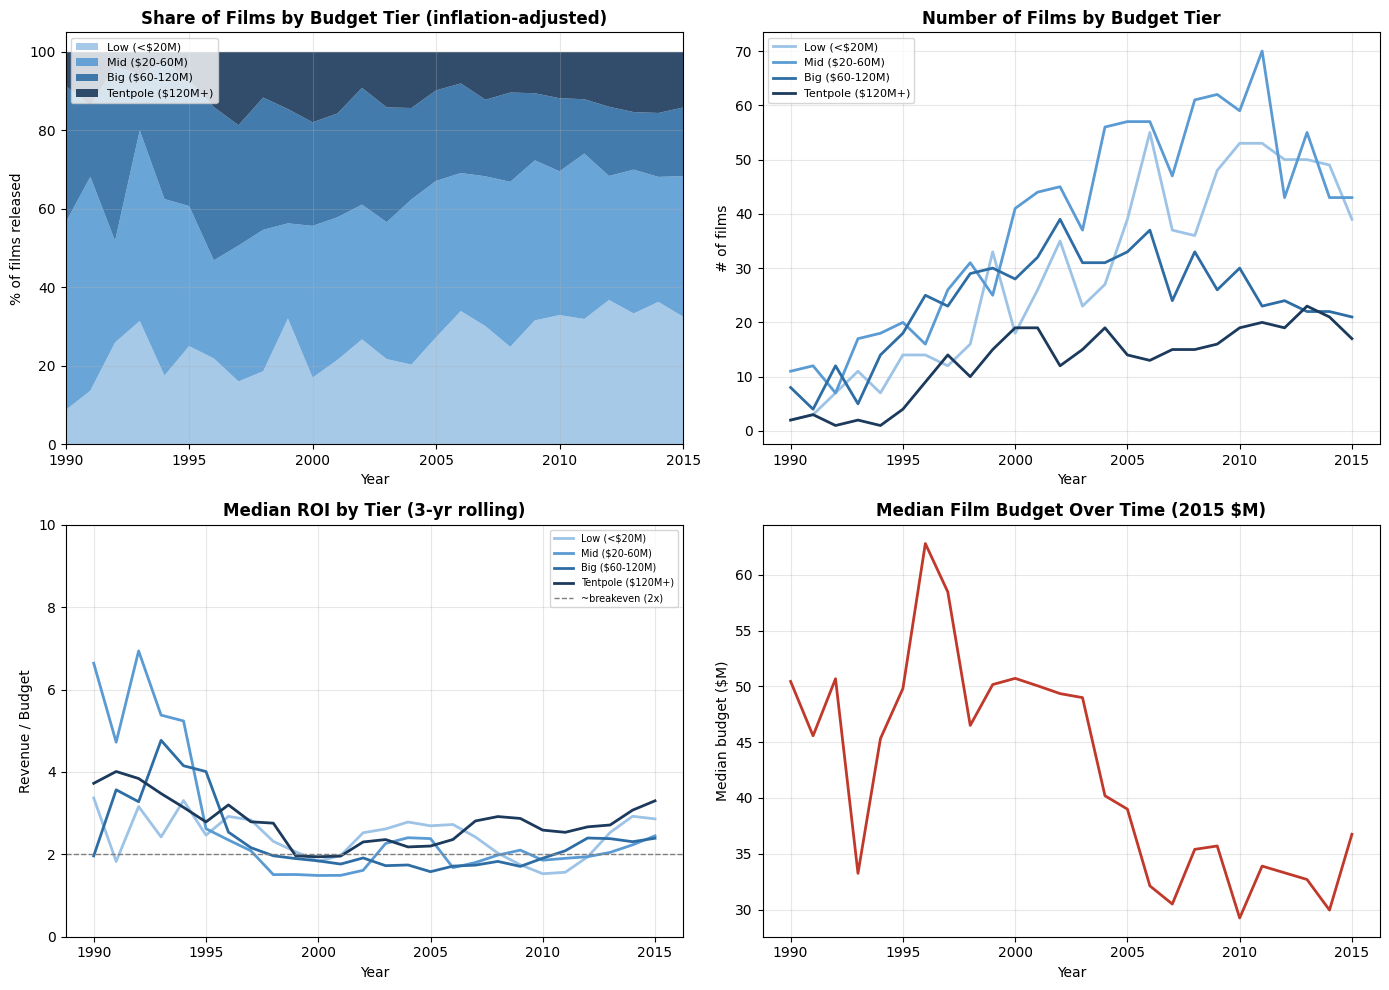

In [8]:
counts = clean.groupby(['year','budget_tier'], observed=True).size().unstack(fill_value=0)[BUCKET_ORDER]
shares = counts.div(counts.sum(axis=1), axis=0) * 100

colors = ['#9DC3E6','#5A9BD4','#2E6DA4','#1B3A5C']

fig, axes = plt.subplots(2, 2, figsize=(14,10))

ax = axes[0,0]
ax.stackplot(shares.index, [shares[b] for b in BUCKET_ORDER], labels=BUCKET_ORDER, colors=colors, alpha=0.9)
ax.set_title('Share of Films by Budget Tier (inflation-adjusted)', fontweight='bold')
ax.set_ylabel('% of films released'); ax.set_xlabel('Year')
ax.legend(loc='upper left', fontsize=8); ax.set_xlim(1990,2015)

ax = axes[0,1]
for b,c in zip(BUCKET_ORDER, colors):
    ax.plot(counts.index, counts[b], label=b, color=c, linewidth=2)
ax.set_title('Number of Films by Budget Tier', fontweight='bold')
ax.set_ylabel('# of films'); ax.set_xlabel('Year'); ax.legend(fontsize=8)

roi_by = clean.groupby(['year','budget_tier'], observed=True)['roi'].median().unstack()[BUCKET_ORDER]
roi_roll = roi_by.rolling(3, min_periods=1).mean()
ax = axes[1,0]
for b,c in zip(BUCKET_ORDER, colors):
    ax.plot(roi_roll.index, roi_roll[b], label=b, color=c, linewidth=2)
ax.axhline(2.0, color='gray', linestyle='--', linewidth=1, label='~breakeven (2x)')
ax.set_title('Median ROI by Tier (3-yr rolling)', fontweight='bold')
ax.set_ylabel('Revenue / Budget'); ax.set_xlabel('Year'); ax.legend(fontsize=7); ax.set_ylim(0,10)

avg_budget = clean.groupby('year')['budget_adj'].median() / 1e6
ax = axes[1,1]
ax.plot(avg_budget.index, avg_budget.values, color='#C0392B', linewidth=2)
ax.set_title('Median Film Budget Over Time (2015 $M)', fontweight='bold')
ax.set_ylabel('Median budget ($M)'); ax.set_xlabel('Year')

plt.tight_layout()
plt.savefig('capstone_fig1_tiers.png', dpi=130)
plt.show()


**Reading the charts:**

- **Top-left (share):** the tier that actually shrinks is **"Big" ($60–120M)** — from ~35–44% of films
  in the early '90s to ~14–18% by the 2010s. **True "Mid" ($20–60M) holds roughly steady** around
  35–40% the whole period. This complicates the popular "mid-budget is dead" narrative — it's really
  the *upper-mid / small-studio-picture* range that got squeezed, not the $20–60M range.
- **Top-right (counts):** low-budget (<$20M) film counts rise sharply in absolute terms — this will be
  interrogated for sampling bias in Section 4, since it's the least trustworthy trend in the dataset.
- **Bottom-left (ROI):** every tier's typical return collapses from a "wild west" 3–7x multiple in the
  early '90s to roughly breakeven by the 2000s — the industry became more competitive/efficient across
  the board, not just more polarized between hits and flops.
- **Bottom-right (median budget):** the median budget actually *falls* after 2005, contradicting the
  intuition that "everything is now a $200M tentpole" — the *median* film got cheaper, pulled down by
  the low-budget volume increase.

In [9]:
# Genre composition within the "Big" tier specifically, since that's the one that actually shrank
big_tier = clean[clean['budget_tier'] == 'Big ($60-120M)']
genre_share_by_era = pd.crosstab(
    pd.cut(big_tier['year'], bins=[1989,1999,2009,2015], labels=['1990s','2000s','2010-15']),
    big_tier['primary_genre'],
    normalize='index'
) * 100

top_genres = big_tier['primary_genre'].value_counts().head(6).index
genre_share_by_era[top_genres].round(1)


primary_genre,Action,Comedy,Drama,Adventure,Animation,Crime
year,,,,,,
1990s,23.8,14.9,22.0,12.5,0.6,5.4
2000s,22.3,19.7,16.6,10.8,5.4,5.1
2010-15,24.6,18.3,11.3,9.2,12.7,4.2


## 4. Critical Check: Sampling Bias in the Dataset

Before trusting the low-budget "surge" seen above, it needs to be checked against an independent
benchmark. This is arguably the most important step in the whole analysis: **a rising count in a
crowd-sourced database can mean "more films were made" or it can just mean "the database got more
complete over time."** These have very different implications and need to be told apart before
drawing conclusions.

In [10]:
total_titles_per_year = clean.groupby('year').size()
growth_factor = total_titles_per_year[2015] / total_titles_per_year[1990]

print(f"Titles in this dataset, 1990: {total_titles_per_year[1990]}")
print(f"Titles in this dataset, 2015: {total_titles_per_year[2015]}")
print(f"Growth factor: {growth_factor:.1f}x")
print()
print("Independent benchmark: US/Canada theatrical releases were roughly FLAT,")
print("~600-700 films/year, across this entire period (industry tracking, e.g. MPA/Statista).")


Titles in this dataset, 1990: 23
Titles in this dataset, 2015: 120
Growth factor: 5.2x

Independent benchmark: US/Canada theatrical releases were roughly FLAT,
~600-700 films/year, across this entire period (industry tracking, e.g. MPA/Statista).


**A 7x+ increase in dataset titles against a flat real-world release count is a strong signal of
coverage bias, not a real trend.** As a second check: if this were driven by *better retroactive
data entry* for small older films, we'd expect budget-field completeness to *improve* for recent
years. It doesn't:

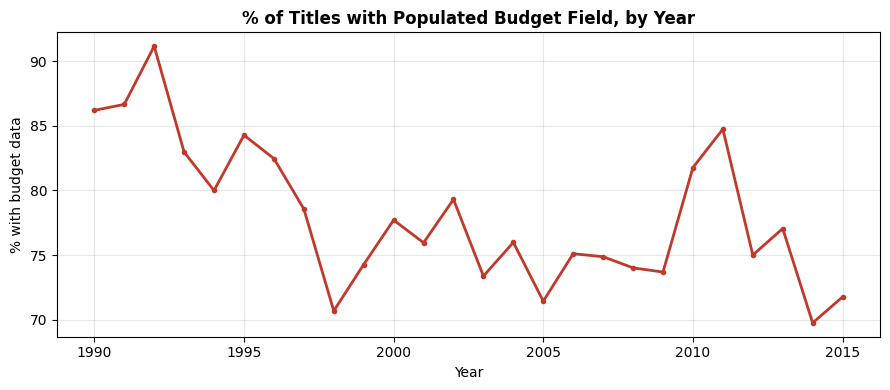

Completeness 1990: 86.2%   Completeness 2015: 71.8%


In [11]:
df_full = df[(df['year']>=1990) & (df['year']<=2015)].copy()
df_full['has_budget'] = df_full['budget'] > 100_000
completeness = df_full.groupby('year')['has_budget'].mean() * 100

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(completeness.index, completeness.values, color='#C0392B', linewidth=2, marker='o', markersize=3)
ax.set_title('% of Titles with Populated Budget Field, by Year', fontweight='bold')
ax.set_ylabel('% with budget data'); ax.set_xlabel('Year')
plt.tight_layout()
plt.savefig('capstone_fig2_completeness.png', dpi=130)
plt.show()

print(f"Completeness 1990: {completeness.loc[1990]:.1f}%   Completeness 2015: {completeness.loc[2015]:.1f}%")


**Conclusion of this section:** budget-field completeness is *flat-to-slightly-declining* over
time (~85% in 1990 vs ~72% in 2015), ruling out "better data entry for small films" as the explanation.
The most likely cause is that this dataset was curated by TMDB's internal *popularity score*, which is
cumulative (views, ratings, list-adds) — so recently-released films have simply had more opportunity
to accumulate popularity and enter a "top 5000" cut, at every budget level, while older obscure titles
never generate enough activity to be included at all.

**Practical implication for the findings above:** the low-budget "surge" (Section 3, top-left/top-right
charts) should be treated as **overstated, and not fully trustworthy** — it's a mix of a real trend
(digital cameras and cheaper post-production genuinely lowered the barrier to entry after ~2005) tangled
with this coverage bias. The **"Big" tier squeeze is more trustworthy**, since $60M+ films were reliably
covered by trade press and industry reporting in every era regardless of TMDB's own catalog maturity.

## 5. Statistical Modeling — What Predicts Box Office Revenue?

Moving beyond description: can we quantify how much of a film's revenue is explained by its budget,
genre, runtime, and audience rating? We log-transform budget and revenue (both are heavily right-skewed
— a handful of blockbusters dominate the raw scale) and fit an OLS regression.

In [12]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model_df = clean.copy()
model_df['log_budget'] = np.log(model_df['budget_adj'])
model_df['log_revenue'] = np.log(model_df['revenue_adj'])

# Keep genres with reasonable sample size to avoid unstable dummy coefficients
top_genres = model_df['primary_genre'].value_counts()
top_genres = top_genres[top_genres >= 30].index
model_df = model_df[model_df['primary_genre'].isin(top_genres)]

formula = 'log_revenue ~ log_budget + runtime + vote_average + C(primary_genre)'
ols = smf.ols(formula, data=model_df).fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.528
Method:                 Least Squares   F-statistic:                     210.8
Date:                Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                        10:40:06   Log-Likelihood:                -4323.5
No. Observations:                2622   AIC:                             8677.
Df Residuals:                    2607   BIC:                             8765.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

**Reading the model:**
- `log_budget`'s coefficient is the model's headline number: it's the % change in revenue per 1%
  change in budget (an elasticity). A coefficient below 1.0 means revenue grows *sub-linearly* with
  budget — bigger budgets don't pay off proportionally, consistent with the ROI compression seen in
  Section 3.
- `vote_average` (audience rating) tests whether quality, independent of budget, predicts commercial
  performance — a positive, significant coefficient would support "good movies make money too," not
  just "expensive movies make money."
- Genre dummy coefficients (relative to the omitted baseline category) show which genres out- or
  under-perform a same-budget, same-rating film in a different genre — this is the fairest way to
  compare genres, since it controls for the fact that some genres are systematically cheaper or more
  expensive to make.
- R-squared indicates how much of the variance in log-revenue this model explains — worth stating
  plainly that a meaningful share of what makes a film a hit (marketing spend, release timing,
  franchise/IP recognition, competition that week) isn't in this dataset at all, so this should be read
  as a partial, not complete, explanation.

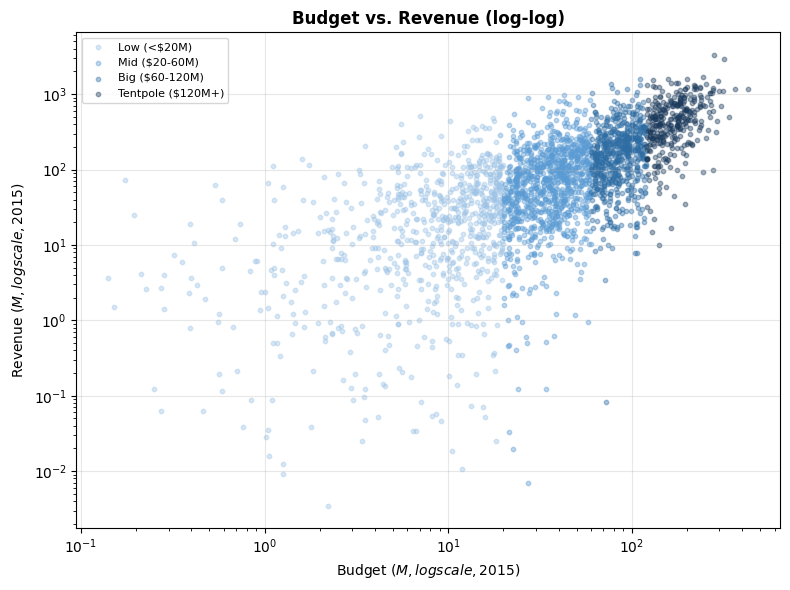

In [13]:
# Visualize budget vs revenue relationship directly, colored by tier
fig, ax = plt.subplots(figsize=(8,6))
tier_colors = dict(zip(BUCKET_ORDER, colors))
for tier in BUCKET_ORDER:
    sub = clean[clean['budget_tier']==tier]
    ax.scatter(sub['budget_adj']/1e6, sub['revenue_adj']/1e6, s=10, alpha=0.4,
               color=tier_colors[tier], label=tier)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Budget ($M, log scale, 2015 $)'); ax.set_ylabel('Revenue ($M, log scale, 2015 $)')
ax.set_title('Budget vs. Revenue (log-log)', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('capstone_fig3_budget_vs_revenue.png', dpi=130)
plt.show()


## 6. Conclusions & Limitations

**Main findings:**
1. The "death of mid-budget movies" as commonly framed is **imprecise**: the $20–60M range held its
   *share* of releases steady from 1990–2015. What actually shrank was the $60–120M range — closer to
   "prestige/upper-mid studio picture" than what most people mean by "mid-budget."
2. ROI compressed across *every* budget tier over the period, not just at the extremes — this is a
   story about the industry getting more competitive/efficient broadly, not just about polarization
   into indies-and-tentpoles.
3. The apparent low-budget "surge" is **partially a sampling artifact** of how this dataset was
   curated, verified against an independent benchmark (flat US theatrical release counts). This is the
   single most important methodological finding in the project: it's a reminder to validate any
   "more of X over time" claim from a single crowd-sourced source against an outside check before
   trusting it.
4. A log-log regression confirms budget is the dominant revenue predictor but with sub-linear
   returns, and genre and audience rating add explanatory power beyond budget alone.

**Limitations:**
- This dataset is not a census of all films made — it's TMDB's own popularity-ranked top ~5,000, which
  we've shown is unevenly complete across years, particularly for older and smaller titles.
- Budget and revenue figures on TMDB are self/studio-reported and not independently audited; some are
  known to be rounded or approximate industry estimates rather than verified figures.
- The regression only includes variables present in this dataset — marketing spend (often comparable
  to or larger than production budget) is not available and is a major omitted variable.
- Inflation adjustment uses a single national CPI series as an approximation; a film-industry-specific
  cost index (accounting for e.g. VFX cost inflation, which has outpaced general CPI) would be more
  precise if available.
